In [63]:
import matplotlib as mpl

mpl.rcParams.update({

    # -------- Lines --------
    "lines.linewidth": 2,
    "lines.markersize": 4.5,

    # -------- Axes labels --------
    "axes.labelsize": 14,
    "axes.titlesize": 14,

    # -------- Tick labels --------
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # -------- Legend --------
    "legend.fontsize": 11,

    # -------- Grid --------
    "grid.alpha": 0.25,

})

plot A function

In [64]:
#import pandas as pd
#import os

#input_file = (
#    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
#    "circadian/mut_project_updates/figures/biomorph/"
#   "plot_a/plot_a_files/"
#    "unified_plotA.txt"
#)

#output_file = (
#    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
#    "circadian/mut_project_updates/figures/biomorph/"
#    "plot_a/plot_a_files/"
#    "unified_plotA_complexity.csv"
#)

#df = pd.read_csv(input_file, sep=r"\s+")

#df = df[df["mutation_type"] == "Random_Sample"][["complexity"]]

#df.to_csv(output_file, index=False)

#print(df.shape)
#print(f"{os.path.getsize(output_file)/1024**2:.2f} MB")

In [65]:
def plot_biomorph_g_top(ax):
    """
    Biomorph G-distribution comparison using the largest available datasets.

    R = 3 : original unified_plotA.txt Random_Sample (1,000,000 genotypes)
    R = 10: biom_500000_10_1_8_30_5_random.txt (500,000 genotypes)
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    # ----------------------------------------------------------
    # Files
    # ----------------------------------------------------------

    old_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/biomorph/"
        "plot_a/plot_a_files/"
        "unified_plotA_complexity.csv"
    )

    new_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/biomorph/"
        "forsam3/biomorphs_sizesAsamples/"
        "biom_500000_10_1_8_30_5_random.txt"
    )

    # ----------------------------------------------------------
    # Original R=3 dataset
    # ----------------------------------------------------------

    g3 = (
        pd.read_csv(old_file)["complexity"]
        .pipe(pd.to_numeric, errors="coerce")
        .dropna()
        .to_numpy()
    )

    g3 = g3[g3 > 0]

    # ----------------------------------------------------------
    # New R=10 dataset
    # ----------------------------------------------------------

    cols = ["genotype", "phenotype", "complexity"]

    df10 = pd.read_csv(
        new_file,
        sep=r"\s+",
        names=cols,
        header=0,
    )

    g10 = (
        pd.to_numeric(df10["complexity"], errors="coerce")
        .dropna()
        .to_numpy()
    )

    g10 = g10[g10 > 0]

    print(f"R=3  : mean = {g3.mean():.3f}   N = {len(g3):,}")
    print(f"R=10 : mean = {g10.mean():.3f}   N = {len(g10):,}")

    # ----------------------------------------------------------
    # Shared bins
    # ----------------------------------------------------------

    bin_width = 15

    xmin = min(g3.min(), g10.min())
    xmax = max(g3.max(), g10.max())

    bins = np.arange(
        np.floor(xmin / bin_width) * bin_width,
        np.ceil(xmax / bin_width) * bin_width + bin_width,
        bin_width,
    )

    c3, edges = np.histogram(g3, bins=bins)
    c10, _ = np.histogram(g10, bins=bins)

    c3 = c3 / c3.sum()
    c10 = c10 / c10.sum()

    centres = 0.5 * (edges[:-1] + edges[1:])

    # ----------------------------------------------------------
    # Colours
    # ----------------------------------------------------------

    light_fill = "#2171b5"
    light_edge = "#2171b5"

    dark_fill = "#08306b"
    dark_edge = "#08306b"
    # ----------------------------------------------------------
    # Plot
    # ----------------------------------------------------------

    # Filled histograms (no edges)
    ax.hist(
        g3,
        bins=bins,
        weights=np.ones_like(g3) / len(g3),
        histtype="stepfilled",
        facecolor=light_fill,
        edgecolor="none",
        alpha=0.35,
        label="R=3",
    )

    ax.hist(
        g10,
        bins=bins,
        weights=np.ones_like(g10) / len(g10),
        histtype="stepfilled",
        facecolor=dark_fill,
        edgecolor="none",
        alpha=0.35,
        label="R=10",
    )

    # Histogram heights for crisp outlines
    c3, _ = np.histogram(g3, bins=bins)
    c10, _ = np.histogram(g10, bins=bins)

    c3 = c3 / c3.sum()
    c10 = c10 / c10.sum()

    ax.set_xlabel("Complexity (Lempel-Ziv)")
    ax.set_ylabel("Relative Frequency")
    ax.set_xlim(0, 450)

    ax.legend(frameon=False)
    ax.set_axisbelow(True)
    ax.minorticks_off()

    return ax

plot B function

In [66]:
def plot_B(ax):
    """
    Biomorph — Plot B
    Entropy vs scaled mean complexity (global scaling).
    """

    import pandas as pd
    from pathlib import Path

    # --------------------------------------------------
    # Load processed biomorph data
    # --------------------------------------------------

    data_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/biomorph/"
        "plot_b/plot_b_files/plotB_biomorph_entropy_global_vs_local.txt"
    )

    df = pd.read_csv(data_file, sep=r"\s+")

    N_values = df["sample_size"].values
    entropy = df["entropy"].values
    scaled_global = df["scaled_global"].values

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    # Entropy (green)
    ax.semilogx(
        N_values, entropy,
        'o-',
        color='green',
        label=r'$S$'
    )

    # Global scaling (orange)
    ax.semilogx(
        N_values, scaled_global,
        'o-',
        color='darkblue',
        label=r'$\langle \tilde{K}_{g} \rangle$'
    )

    ax.set_xlabel('Number of sampled genotypes (N, log scale)')
    ax.set_ylabel(r'Entropy (S) and scaled $\langle \tilde{K}_{g} \rangle$')
    ax.set_xscale("log")
    ax.minorticks_off()

    ax.grid(True, which="major", linestyle="-", alpha=0.2)

    ax.legend(frameon=False)

plot C function

In [67]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

raw = pd.read_csv(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/biomorph/biomor_sam/unified_plotC_genomesize.txt",
    sep=r"\s+"
)

def shannon_entropy(x):
    p = x.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

rows = []

for size in sorted(raw["size"].unique()):

    df = raw[raw["size"] == size].copy()

    # sample WITHOUT replacement
    df = df.sample(
        n=50000,
        replace=False,
        random_state=42,
    )

    rows.append({
        "genome_size": size,
        "KC": df["complexity"].mean(),
        "shannon_entropy": shannon_entropy(df["phenotype"]),
        "N": len(df),
    })

plotC_equalN = pd.DataFrame(rows)

print(plotC_equalN)

plotC_equalN.drop(columns="N").to_csv(
    "plotC_data_equalN.txt",
    sep=" ",
    index=False
)

def plot_C(ax):
    """
    Biomorph — Plot C
    Mean KC vs Shannon entropy (linear regression).
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    data_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/biomorph/"
        "plot_c/plotC_data_equalN.txt"
    )

    df = pd.read_csv(data_path, sep=r"\s+")

    df["genome_size"] = pd.to_numeric(df["genome_size"], errors="coerce")
    df["KC"] = pd.to_numeric(df["KC"], errors="coerce")
    df["shannon_entropy"] = pd.to_numeric(df["shannon_entropy"], errors="coerce")

    df = df.dropna()

    entropy_vals = df["shannon_entropy"].values
    kc_vals = df["KC"].values
    labels = df["genome_size"].astype(int).astype(str).values

    # Linear regression
    m, b = np.polyfit(entropy_vals, kc_vals, 1)
    fit_line = m * entropy_vals + b
    sign = "-" if b < 0 else "+"
    eq_label = rf"$\langle \tilde{{K}}_{{g}} \rangle = {m:.2f}\,S {sign} {abs(b):.2f}$"

    ax.scatter(entropy_vals, kc_vals, color='darkblue')
    ax.plot(entropy_vals, fit_line, color='darkblue', label=eq_label)

    for xi, yi, lbl in zip(entropy_vals, kc_vals, labels):
        ax.text(xi, yi, lbl, fontsize=11, ha='center', va='bottom')

    ax.set_xlabel("Shannon Entropy (S)")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")
    #ax.grid(True, which="major", linestyle="-", alpha=0.2)
    ax.margins(x=0.05, y=0.05)
    ax.legend(frameon=False)

   genome_size          KC  shannon_entropy      N
0            2  143.068293        12.471623  50000
1            3  146.074101        13.038922  50000
2            4  148.664691        13.317728  50000
3            7  149.627289        13.619333  50000
4           10  150.578340        13.770815  50000


plot D function

In [68]:
def plot_D(ax):
    """
    Biomorph — Plot D
    Mean KC vs mutation number grouped by quintile.
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    data_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
        "mut_project_updates/figures/biomorph/plot_d/plotD_data_incl0.txt"
    )

    marker = "o"

    # --------------------------------
    # Load data
    # --------------------------------
    df = pd.read_csv(data_path, sep=r"\s+")

    df["n_mutations"] = pd.to_numeric(df["n_mutations"], errors="coerce")
    df["mean_KC"] = pd.to_numeric(df["mean_KC"], errors="coerce")
    df["quintile"] = pd.to_numeric(df["quintile"], errors="coerce")

    df = df.dropna(subset=["n_mutations", "mean_KC", "quintile"])

    df["n_mutations"] = df["n_mutations"].astype(int)
    df["quintile"] = df["quintile"].astype(int)

    # Pivot table
    pivot = df.pivot_table(index="n_mutations",
                           columns="quintile",
                           values="mean_KC",
                           aggfunc="mean")

    pivot = pivot.sort_index()

    quints = sorted(pivot.columns)

    x_positions = np.arange(len(pivot.index))
    x_tick_labels = [str(int(x)) for x in pivot.index]

    # --------------------------------
    # Plot (pink → plum gradient G1 → G5)
    # --------------------------------
    palette = [
        "#B8D8F8",
        "#7FB3E6",
        "#4F8FCC",
        "#2F5F99",
        "#163B66",
    ]

    for i, q in enumerate(quints):
        ax.plot(x_positions,
                pivot[q].to_numpy(),
                marker=marker,
                color=palette[i],
                label=f"G{q}")

    ax.set_xlabel("Number of mutations")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")

    # show every other tick
    ax.set_xticks(x_positions[::2])
    ax.set_xticklabels(x_tick_labels[::2])

    ax.grid(True, which="major", linestyle="-", alpha=0.2)

    # Reverse legend (G5 → G1)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc="upper right",
              frameon=False)

    # 0.5 tick spacing margin
    if len(x_positions) > 1:
        spacing = x_positions[1] - x_positions[0]
    else:
        spacing = 1.0

    ax.set_xlim(x_positions[0] - 0.5 * spacing,
                x_positions[-1] + 0.5 * spacing)

## compare L=3, N=2.73M (unified A) and L=3, N=100k (forsam3) datasets

R=3  : mean = 146.431   N = 1,000,000
R=10 : mean = 150.321   N = 500,000


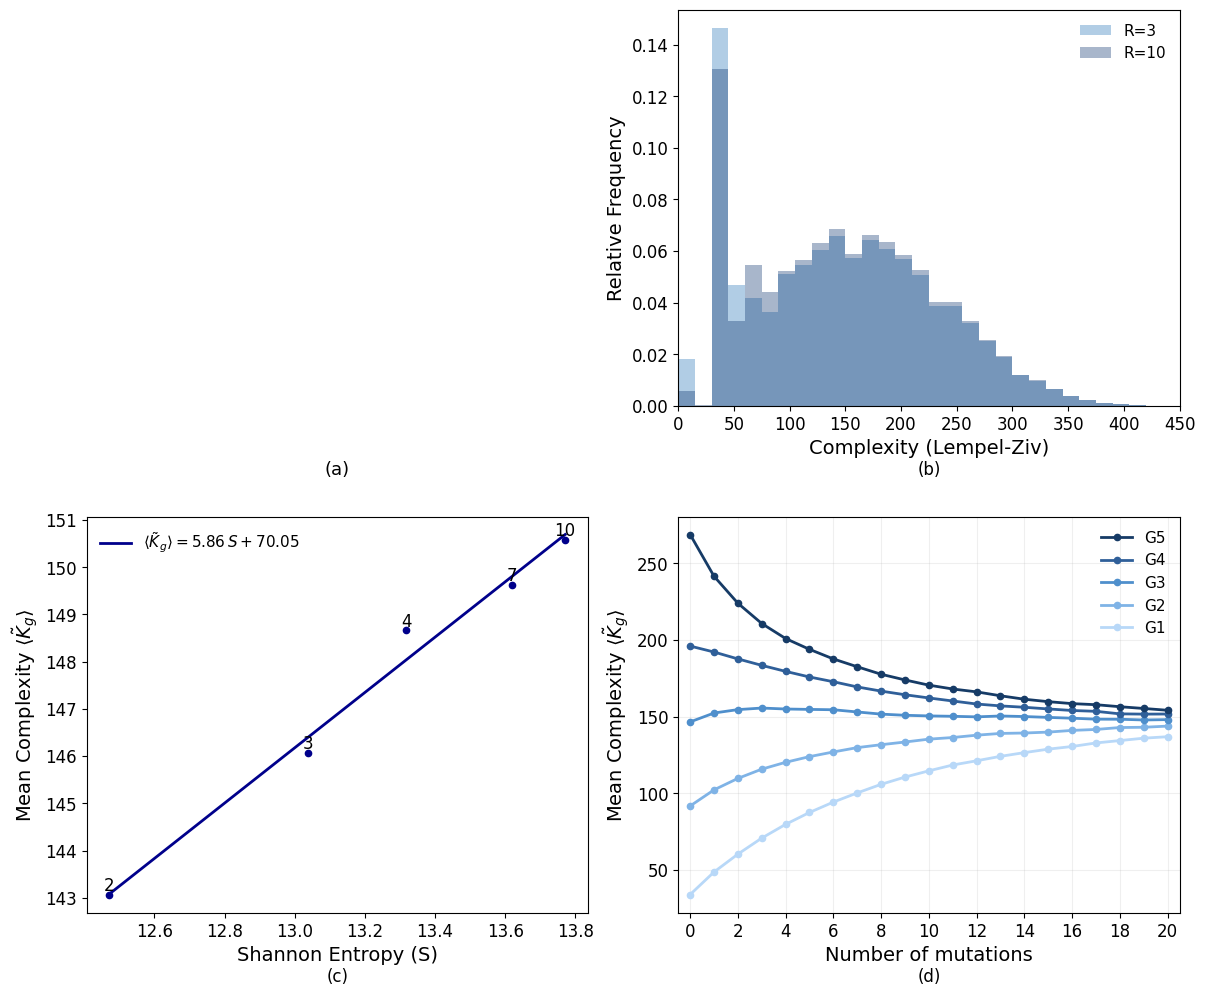

In [69]:
import matplotlib.pyplot as plt
from PIL import Image
import subprocess
import os

# ===================================
# Figure layout: 2 × 2
# ===================================

fig = plt.figure(figsize=(12, 10))

# Panel (a) - blank
ax_blank = plt.subplot2grid((2, 2), (0, 0))
ax_blank.axis("off")

# Existing panels
ax_top = plt.subplot2grid((2, 2), (0, 1))
ax_bl  = plt.subplot2grid((2, 2), (1, 0))
ax_br  = plt.subplot2grid((2, 2), (1, 1))

# ===================================
# Plotting
# ===================================

plot_biomorph_g_top(ax_top)
plot_C(ax_bl)
plot_D(ax_br)

# ===================================
# Panel labels
# ===================================

ax_blank.text(
    0.5, -0.14, "(a)",
    transform=ax_blank.transAxes,
    ha="center", va="top",
    fontsize=13
)

ax_top.text(
    0.5, -0.14, "(b)",
    transform=ax_top.transAxes,
    ha="center", va="top",
    fontsize=13
)

ax_bl.text(
    0.5, -0.14, "(c)",
    transform=ax_bl.transAxes,
    ha="center", va="top",
    fontsize=13
)

ax_br.text(
    0.5, -0.14, "(d)",
    transform=ax_br.transAxes,
    ha="center", va="top",
    fontsize=13
)

# ===================================
# Styling
# ===================================

LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11
ANNOT_SIZE = 12

for ax in [ax_top, ax_bl, ax_br]:
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_SIZE)

    for text in ax.texts:
        text.set_fontsize(ANNOT_SIZE)

plt.tight_layout()
plt.subplots_adjust(hspace=0.28, wspace=0.18)
plt.show()